# E-Commerce Personalization Platform - Data Pipeline Notebook

## 1. Data Fetching
This section retrieves the UCI Online Retail dataset using the ucimlrepo library.

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
X = online_retail.data.features 
y = online_retail.data.targets 
  
# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

## 2. Data Loading and Initial Inspection
Assign the features to a working DataFrame and perform initial checks on structure and content.

In [2]:
# Assign features to df for consistency 
df = X # Features DataFrame (541k rows, 8 columns)
print(f'Shape: {df.shape}\n') # Expected: (541909, 8)
print(f"First 5 Rows:\n{df.head()}\n") # Verify loading
print(f"Data Info:\n{df.info()}") # Show dtypes and null counts
print(f"Summary Statistics:\n{df.describe()}") # Basic stats
print(f"Missing Values:\n{df.isnull().sum()}") # Check for nulls

Shape: (541909, 6)

First 5 Rows:
                           Description  Quantity     InvoiceDate  UnitPrice  \
0   WHITE HANGING HEART T-LIGHT HOLDER         6  12/1/2010 8:26       2.55   
1                  WHITE METAL LANTERN         6  12/1/2010 8:26       3.39   
2       CREAM CUPID HEARTS COAT HANGER         8  12/1/2010 8:26       2.75   
3  KNITTED UNION FLAG HOT WATER BOTTLE         6  12/1/2010 8:26       3.39   
4       RED WOOLLY HOTTIE WHITE HEART.         6  12/1/2010 8:26       3.39   

   CustomerID         Country  
0     17850.0  United Kingdom  
1     17850.0  United Kingdom  
2     17850.0  United Kingdom  
3     17850.0  United Kingdom  
4     17850.0  United Kingdom  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate

## 3. Data Visualization
Generate initial plots to explore data distributions and patterns using Seaborn and Matplotlib

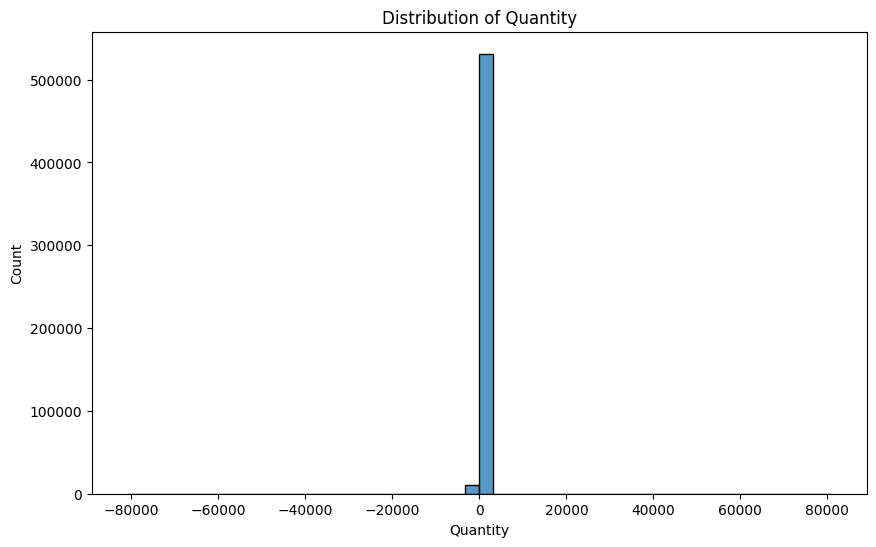

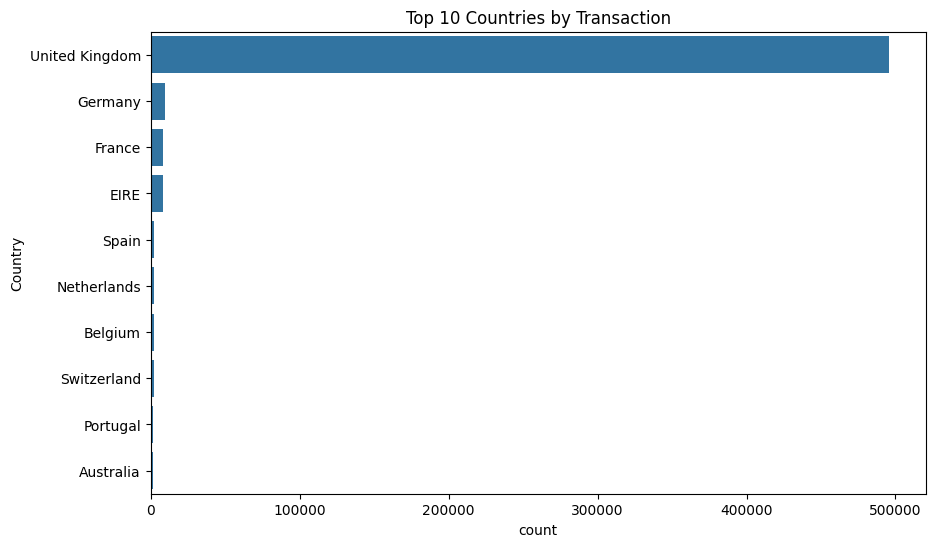

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Quantity distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Quantity'], bins=50)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.show()

# Top 10 countries by transaction count
plt.figure(figsize=(10, 6))
sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index[:10])
plt.title('Top 10 Countries by Transaction')
plt.show()

## 4. Data Preprocessing (Initial)
Begin preprocessing by converting date formats and calculating total spend, setting up for RFM. Data is saved locally as 'data/online_retail_processed.csv' for offline use.

In [6]:
import pandas as pd

# Convert InvoiceDate to datetime and calculate TotalSpend
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.loc[:, 'TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Save the preprocessed DataFrame to a local CSV file
df.to_csv('data/online_retail_processed.csv', index=False)
print("Data saved locally as 'data/online_retail_processed.csv'")

df_check = pd.read_csv('data/online_retail_processed.csv')
print(df_check.head())

# Note: RFM grouping will follow after cleaning (Day 2)

Data saved locally as 'data/online_retail_processed.csv'
                           Description  Quantity          InvoiceDate  \
0   WHITE HANGING HEART T-LIGHT HOLDER         6  2010-12-01 08:26:00   
1                  WHITE METAL LANTERN         6  2010-12-01 08:26:00   
2       CREAM CUPID HEARTS COAT HANGER         8  2010-12-01 08:26:00   
3  KNITTED UNION FLAG HOT WATER BOTTLE         6  2010-12-01 08:26:00   
4       RED WOOLLY HOTTIE WHITE HEART.         6  2010-12-01 08:26:00   

   UnitPrice  CustomerID         Country  TotalSpend  
0       2.55     17850.0  United Kingdom       15.30  
1       3.39     17850.0  United Kingdom       20.34  
2       2.75     17850.0  United Kingdom       22.00  
3       3.39     17850.0  United Kingdom       20.34  
4       3.39     17850.0  United Kingdom       20.34  


## 5. Data Exploration
Perform additional analysis to identify trends, outliers, and key insights.

In [5]:
# Date range of transactions
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# Top 10 Products by frequency
print("Top 10 Products by Frequency:")
print(df['Description'].value_counts().head(10))

# Outlier check for quantity and UnitPrice
print(f"Quantity Outliers (min/max): {df['Quantity'].min()} {df['Quantity'].max()}")
print(f"UnitPrice Outliers (min/max): {df['UnitPrice'].min()} {df['UnitPrice'].max()}")

Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Top 10 Products by Frequency:
Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64
Quantity Outliers (min/max): -80995 80995
UnitPrice Outliers (min/max): -11062.06 38970.0
